<a href="https://colab.research.google.com/github/codeSamuraii/ml-experiments/blob/main/DimensionReductionVideo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensionality Reduction on Video

This notebook applies classical dimensionality reduction to video data in two ways:

1. **Time compression** — represent an entire clip as one or more images (PCA, NMF, Robust PCA).
2. **Channel compression** — collapse RGB to a single greyscale channel (PCA).

Each method has its own section with background, variations, and **individual figures** (no bundled multi-panel renders).

An optional **t-SNE** section at the end explores frame similarity without producing a compressed image.


## Setup
Install dependencies and generate a sample video.

In [1]:
!source .venv/bin/activate

In [2]:
!pip install -q numpy scikit-learn Pillow matplotlib

### Generate sample video
We use ffmpeg's `testsrc2` to quickly produce a short 720p test video.

If you want the rotating cube video, run `python tests/samples/generate.py` instead (requires numpy, Pillow, and ffmpeg).

In [3]:
import subprocess
import os

SAMPLE_DIR = "tests/samples"
os.makedirs(SAMPLE_DIR, exist_ok=True)
SAMPLE_VIDEO = os.path.join(SAMPLE_DIR, "720p.mp4")

if not os.path.exists(SAMPLE_VIDEO):
    subprocess.run([
        "ffmpeg", "-y",
        "-f", "lavfi",
        "-i", "testsrc2=size=1280x720:rate=30:duration=10",
        "-c:v", "libx264", "-preset", "fast", "-crf", "18",
        "-pix_fmt", "yuv420p",
        SAMPLE_VIDEO,
    ], capture_output=True, check=True)
    print(f"Generated {SAMPLE_VIDEO}")
else:
    print(f"Using existing {SAMPLE_VIDEO}")

Using existing tests/samples/720p.mp4


## Loading video frames
Extract frames from the video using ffmpeg and load them as numpy arrays.

In [4]:
import numpy as np
from PIL import Image
import io
import struct

def extract_frames(video_path, max_frames=120, resize=(320, 180)):
    """Extract frames from a video file using ffmpeg.

    Returns an array of shape (N, H, W, 3) with uint8 RGB values.
    """
    w, h = resize
    cmd = [
        "ffmpeg", "-i", video_path,
        "-vframes", str(max_frames),
        "-s", f"{w}x{h}",
        "-f", "rawvideo", "-pix_fmt", "rgb24",
        "pipe:1",
    ]
    result = subprocess.run(cmd, capture_output=True, check=True)
    raw = result.stdout
    frame_size = w * h * 3
    n_frames = len(raw) // frame_size
    frames = np.frombuffer(raw[:n_frames * frame_size], dtype=np.uint8)
    frames = frames.reshape(n_frames, h, w, 3)
    return frames

frames = extract_frames(SAMPLE_VIDEO, max_frames=120, resize=(320, 180))
print(f"Loaded {frames.shape[0]} frames of shape {frames.shape[1:]} (H, W, C)")

Loaded 120 frames of shape (180, 320, 3) (H, W, C)


### Sample frames from the video

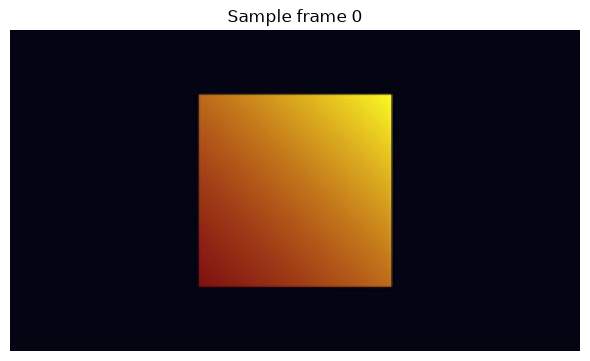

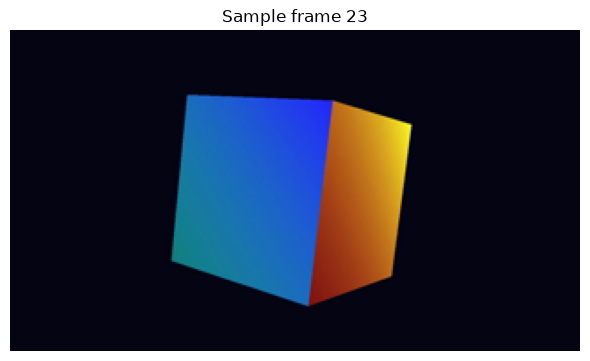

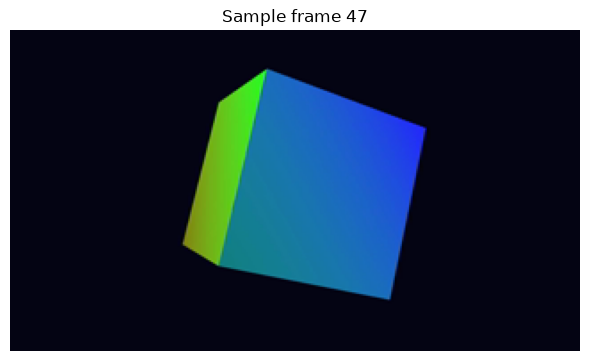

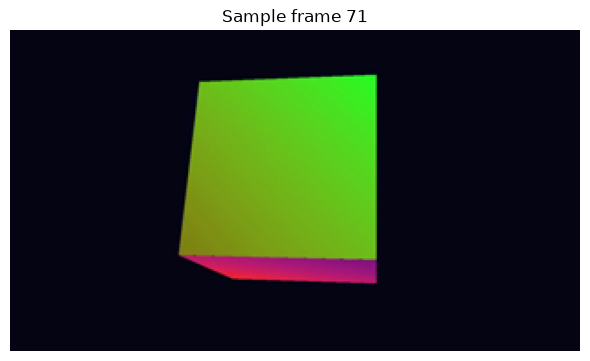

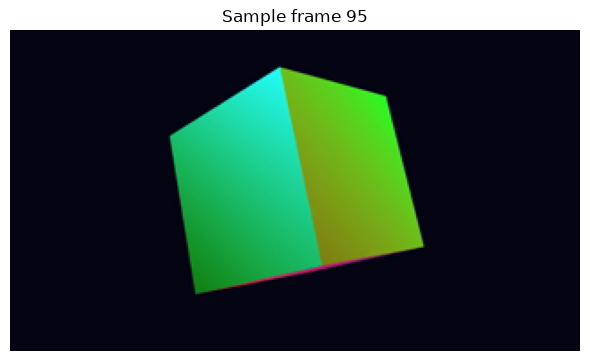

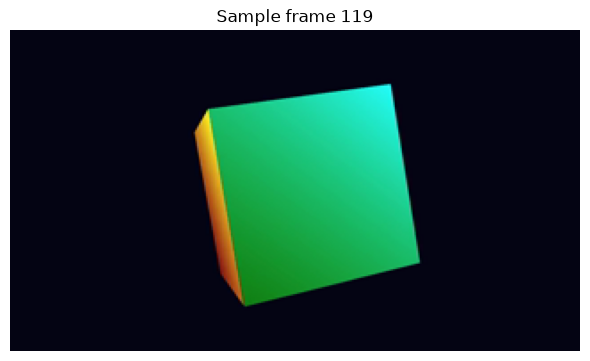

In [5]:
import matplotlib.pyplot as plt

indices = np.linspace(0, len(frames) - 1, 6, dtype=int)
for idx in indices:
    plt.figure(figsize=(6, 4))
    plt.imshow(frames[idx])
    plt.title(f"Sample frame {idx}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close()


## Experiment 1: Time dimension reduction

### Problem setup

A video with `N` frames of size `H×W` is treated as a matrix **X** of shape `(N, H·W·3)`:

| row | content |
|-----|---------|
| row *i* | flattened RGB values of frame *i* |

The goal is to summarise the **time axis** with one or more images that live in pixel space.

Methods that succeed produce **basis images** (or a background image) you can `reshape(H, W, 3)` and display. Methods like t-SNE only give coordinates and are covered separately at the end.


### Shared utilities


In [6]:
def _rescale_to_uint8(image):
    """Rescale a float image to uint8 for display."""
    lo, hi = image.min(), image.max()
    scaled = (image - lo) / (hi - lo + 1e-8) * 255
    return scaled.astype(np.uint8)


def show_image(image, title="", cmap=None, figsize=(7, 5)):
    """Display a single image in its own figure."""
    plt.figure(figsize=figsize)
    if cmap is None:
        plt.imshow(image)
    else:
        plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close()


## PCA — Principal Component Analysis

### How it works

PCA finds orthogonal directions of maximum variance. After centering the data (subtracting the temporal mean), it solves:

$$\mathbf{X}_{\text{centered}} \approx \mathbf{W} \mathbf{H}$$

where rows of **H** are principal components — each a vector in pixel space.

| Symbol | Meaning |
|--------|---------|
| $\mathbf{h}_1$ | Direction of greatest frame-to-frame variation |
| $w_{i1}$ | How much frame *i* projects onto component 1 |
| `explained_variance_ratio_` | Fraction of total variance captured by each component |

**Key properties for video:**
- Components are **signed** — positive and negative pixel values are allowed.
- Component 1 often resembles a blurred temporal average.
- Higher components capture **differences** between frames (motion, lighting).
- PCA is a **linear** method: reconstructed frames are linear combinations of components.


In [7]:
from sklearn.decomposition import PCA


def pca_reduce_time(frames, n_components=1):
    """Fit PCA across the time axis and return component images."""
    n, h, w, c = frames.shape
    flat = frames.reshape(n, -1).astype(np.float64)

    pca = PCA(n_components=n_components)
    pca.fit(flat)

    components = [
        _rescale_to_uint8(comp.reshape(h, w, c))
        for comp in pca.components_
    ]
    return np.array(components), pca, flat


def pca_reconstruct(flat, pca):
    """Reconstruct all frames from a fitted PCA model."""
    recon = pca.inverse_transform(pca.transform(flat))
    mse = ((flat - recon) ** 2).mean(axis=1)
    return recon, mse


### PCA variation 1 — First principal component (k = 1)

The first component is the single best linear summary of the clip. It captures the dominant shared appearance.


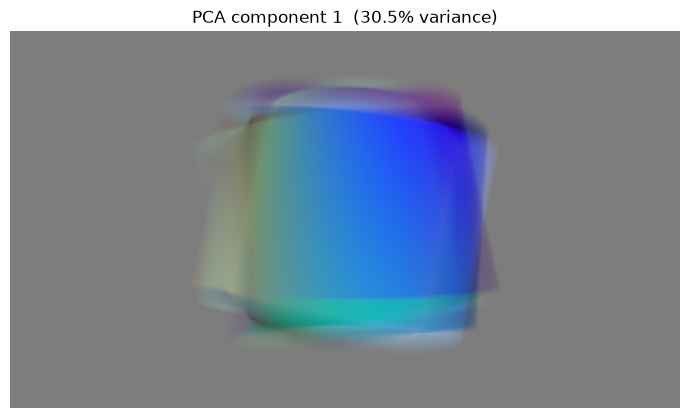

In [8]:
pca_k1, pca_model_k1, flat = pca_reduce_time(frames, n_components=1)

show_image(
    pca_k1[0],
    title=f"PCA component 1  ({pca_model_k1.explained_variance_ratio_[0]*100:.1f}% variance)",
)


### PCA variation 2 — Temporal weights

Each frame is projected onto the principal components. Plotting these weights over time shows *when* each mode is active.

For a periodic test pattern, weights often oscillate. For a scene cut, you would see a step change.


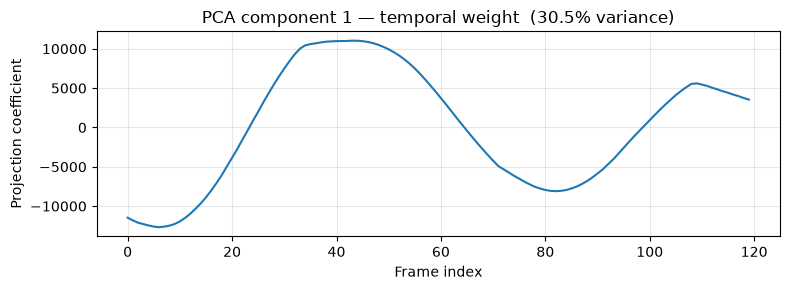

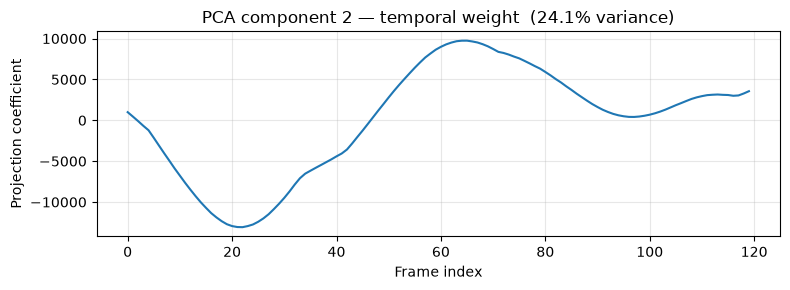

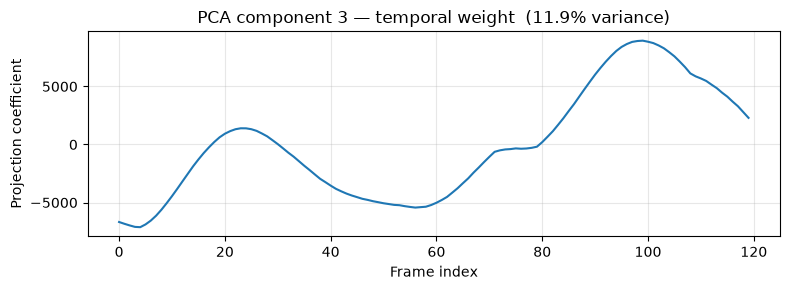

In [9]:
_, pca_model_w, flat = pca_reduce_time(frames, n_components=3)
weights = pca_model_w.transform(flat)  # shape (N, k)

for i in range(weights.shape[1]):
    plt.figure(figsize=(8, 3))
    plt.plot(weights[:, i], linewidth=1.5)
    pct = pca_model_w.explained_variance_ratio_[i] * 100
    plt.title(f"PCA component {i+1} — temporal weight  ({pct:.1f}% variance)")
    plt.xlabel("Frame index")
    plt.ylabel("Projection coefficient")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


### PCA variation 3 — Individual higher-order components

Components 2, 3, … capture progressively smaller deviations from the mean. Each is shown separately below (k = 5 fit, components 1–5 displayed one at a time).


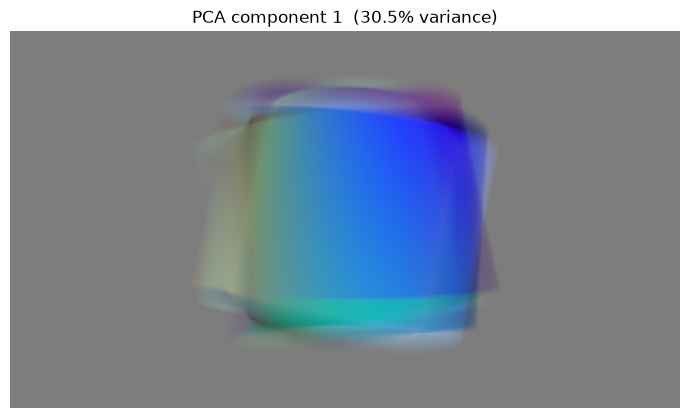

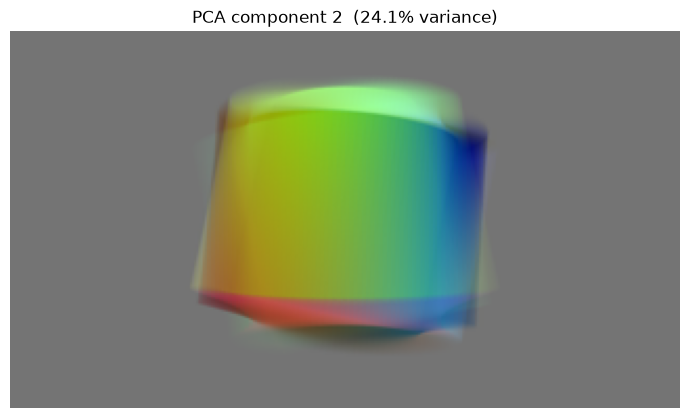

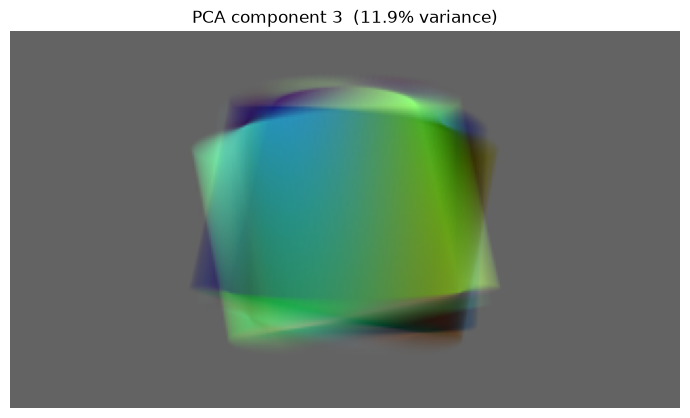

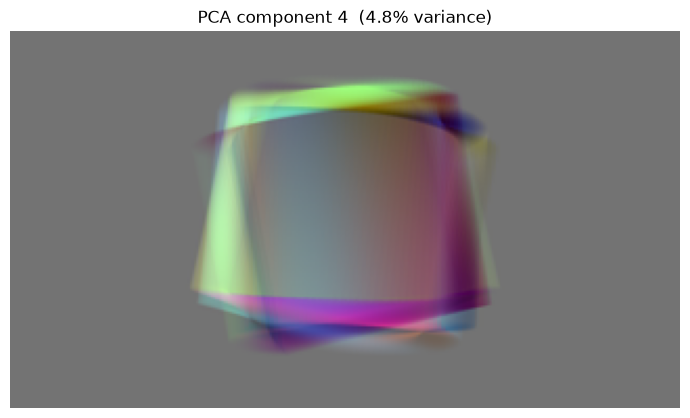

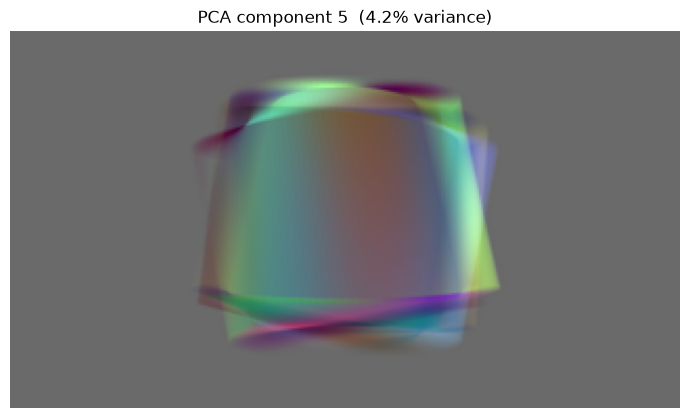

In [10]:
pca_k5, pca_model_k5, _ = pca_reduce_time(frames, n_components=5)

for i, comp in enumerate(pca_k5):
    pct = pca_model_k5.explained_variance_ratio_[i] * 100
    show_image(comp, title=f"PCA component {i+1}  ({pct:.1f}% variance)")


### PCA variation 4 — Scree plot (how many components?)

The cumulative variance curve helps choose *k*. The elbow is often a good trade-off between compression and fidelity.


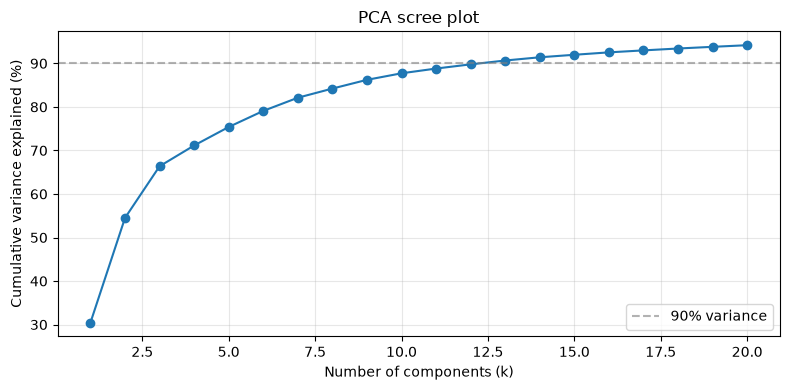

In [11]:
max_k = min(len(frames), 20)
_, pca_scree, _ = pca_reduce_time(frames, n_components=max_k)
cumvar = np.cumsum(pca_scree.explained_variance_ratio_) * 100

plt.figure(figsize=(8, 4))
plt.plot(range(1, max_k + 1), cumvar, "o-")
plt.axhline(90, color="gray", linestyle="--", alpha=0.6, label="90% variance")
plt.xlabel("Number of components (k)")
plt.ylabel("Cumulative variance explained (%)")
plt.title("PCA scree plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


### PCA variation 5 — Reconstruction quality vs k

Reconstruct every frame using only the first *k* components and measure per-frame MSE. Compare a low-k (lossy) and high-k (faithful) setting.


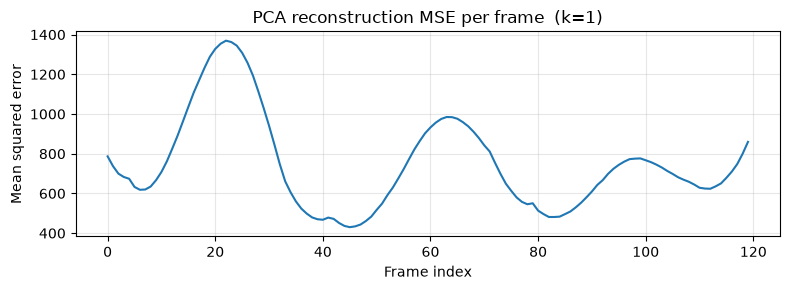

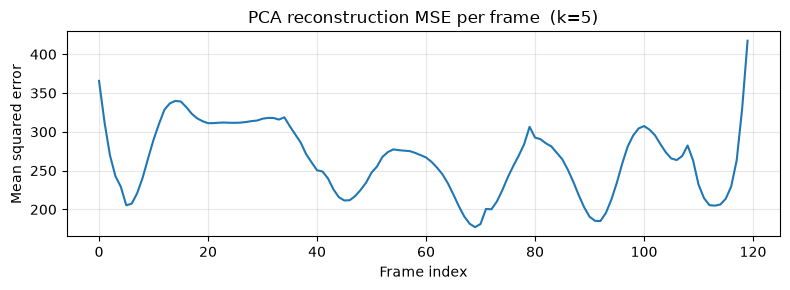

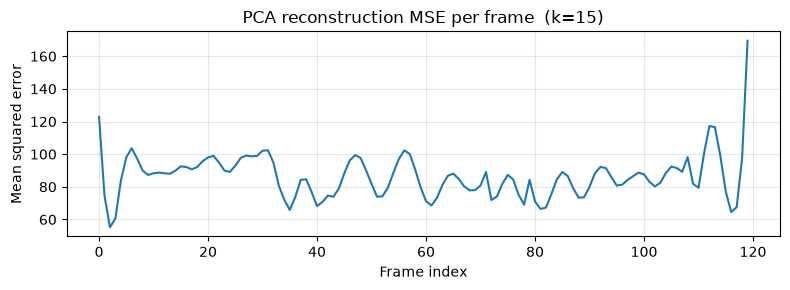

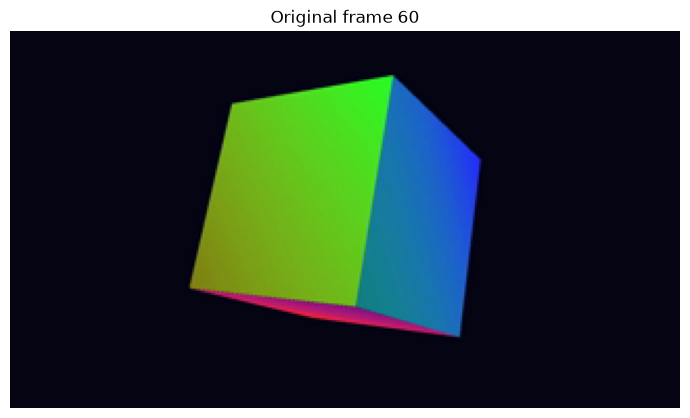

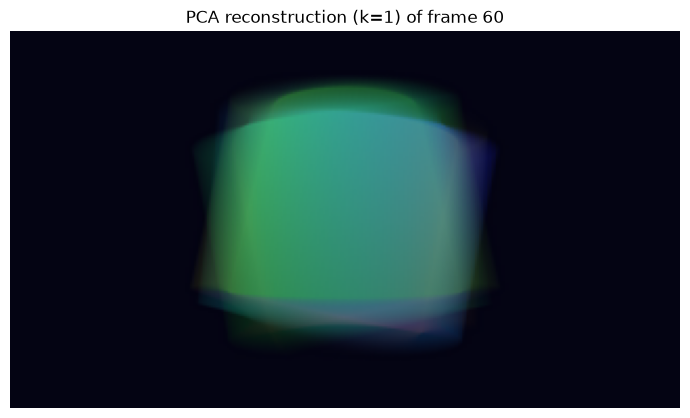

In [12]:
for k in [1, 5, 15]:
    _, pca_recon, flat = pca_reduce_time(frames, n_components=k)
    recon, mse = pca_reconstruct(flat, pca_recon)

    plt.figure(figsize=(8, 3))
    plt.plot(mse, linewidth=1.5)
    plt.title(f"PCA reconstruction MSE per frame  (k={k})")
    plt.xlabel("Frame index")
    plt.ylabel("Mean squared error")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

# Visual check on a single frame: original vs k=1 reconstruction
mid = len(frames) // 2
_, pca_r1, flat = pca_reduce_time(frames, n_components=1)
recon, _ = pca_reconstruct(flat, pca_r1)
n, h, w, c = frames.shape

show_image(frames[mid], title=f"Original frame {mid}")
show_image(
    recon[mid].reshape(h, w, c).clip(0, 255).astype(np.uint8),
    title=f"PCA reconstruction (k=1) of frame {mid}",
)


## NMF — Non-negative Matrix Factorization

### How it works

NMF factorises **X ≈ W H** with the constraint that all entries of **W** and **H** are ≥ 0:

| Symbol | Shape | Meaning |
|--------|-------|---------|
| **H** | (k, pixels) | k non-negative basis images |
| **W** | (N, k) | non-negative activation per frame |

**Differences from PCA:**
- **No negative pixel values** — bases look like images you could physically add together.
- **Parts-based** — each basis often captures a distinct visual element.
- **No orthogonality** — bases can overlap.
- Reconstruction error is explicit (`reconstruction_err_`).

Unlike PCA, NMF does not centre the data; it models frames as additive combinations of bright patterns.


In [13]:
from sklearn.decomposition import NMF


def nmf_reduce_time(frames, n_components=1, random_state=42, init="nndsvda"):
    """Fit NMF across the time axis and return basis images."""
    n, h, w, c = frames.shape
    flat = frames.reshape(n, -1).astype(np.float64)

    nmf = NMF(
        n_components=n_components,
        init=init,
        max_iter=1000,
        random_state=random_state,
    )
    nmf.fit(flat)

    bases = [
        _rescale_to_uint8(basis.reshape(h, w, c))
        for basis in nmf.components_
    ]
    return np.array(bases), nmf


### NMF variation 1 — Single basis (k = 1)

With one component, the basis is the single non-negative image that best reconstructs all frames via scaling.


/Users/remi/Programs/other/ml-experiments/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


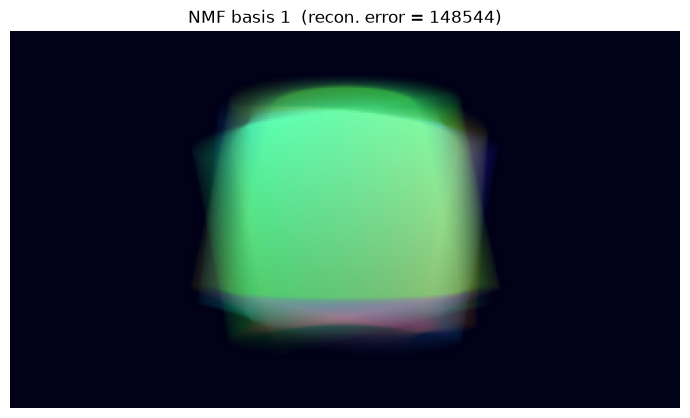

In [14]:
nmf_k1, nmf_model_k1 = nmf_reduce_time(frames, n_components=1)

show_image(nmf_k1[0], title=f"NMF basis 1  (recon. error = {nmf_model_k1.reconstruction_err_:.0f})")


### NMF variation 2 — Temporal activations

The matrix **W** tells us how strongly each basis contributes to each frame. High activation means that basis is prominent at that time.


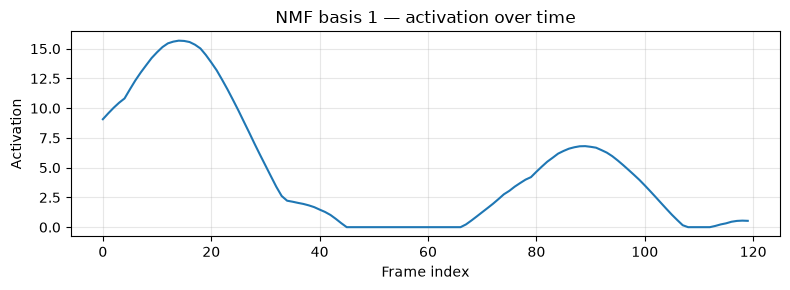

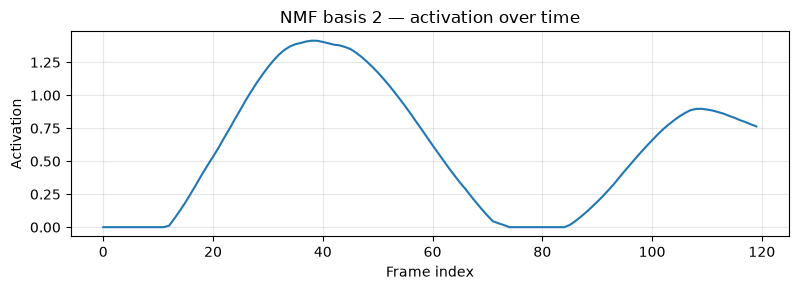

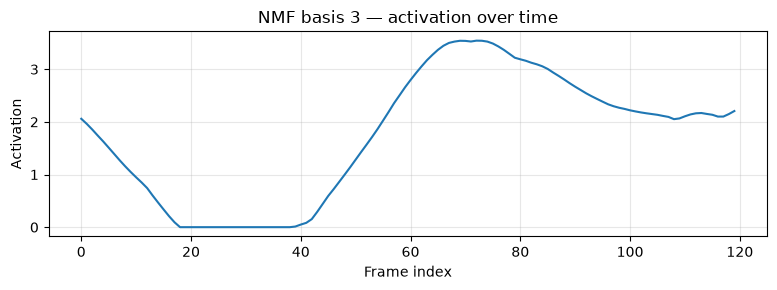

In [15]:
_, nmf_model_w = nmf_reduce_time(frames, n_components=3)
activations = nmf_model_w.transform(frames.reshape(len(frames), -1).astype(np.float64))

for i in range(activations.shape[1]):
    plt.figure(figsize=(8, 3))
    plt.plot(activations[:, i], linewidth=1.5)
    plt.title(f"NMF basis {i+1} — activation over time")
    plt.xlabel("Frame index")
    plt.ylabel("Activation")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


### NMF variation 3 — Multiple bases (k = 5)

Each basis is displayed in its own figure. Compare with PCA components: NMF bases are strictly non-negative.


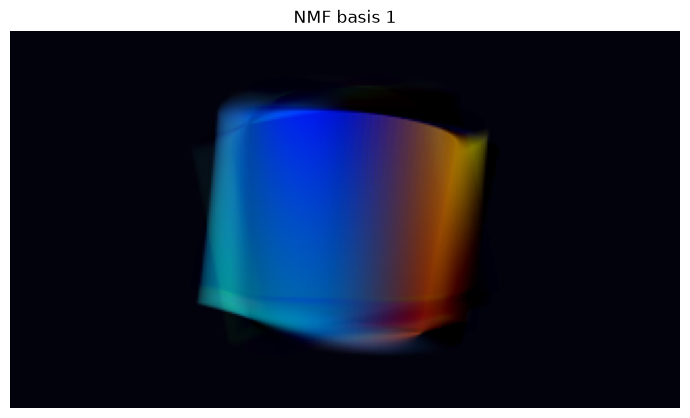

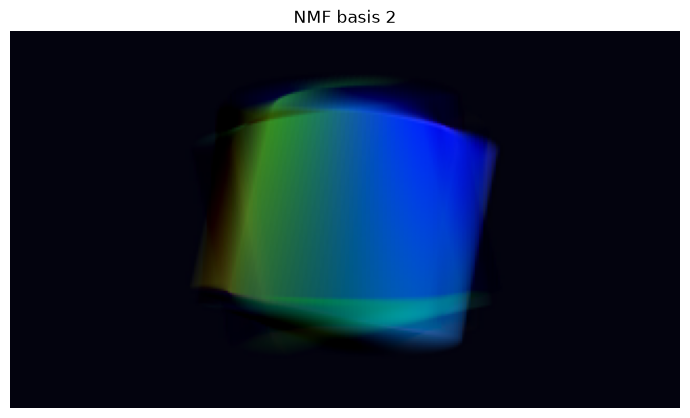

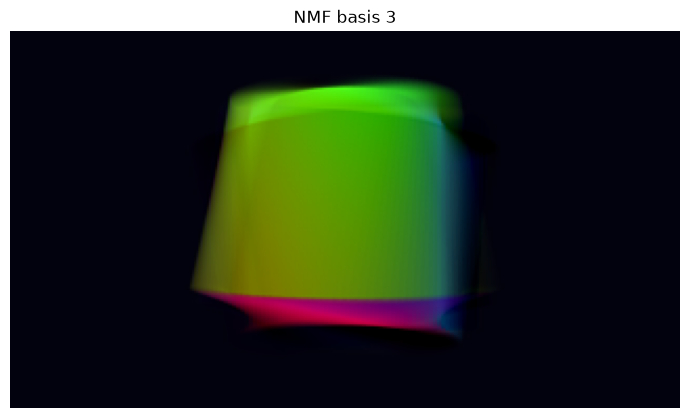

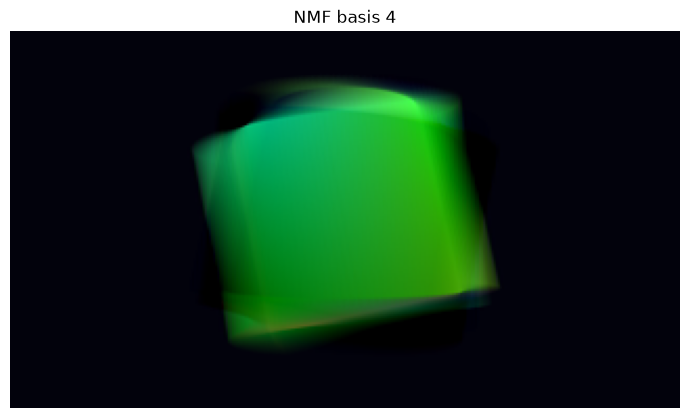

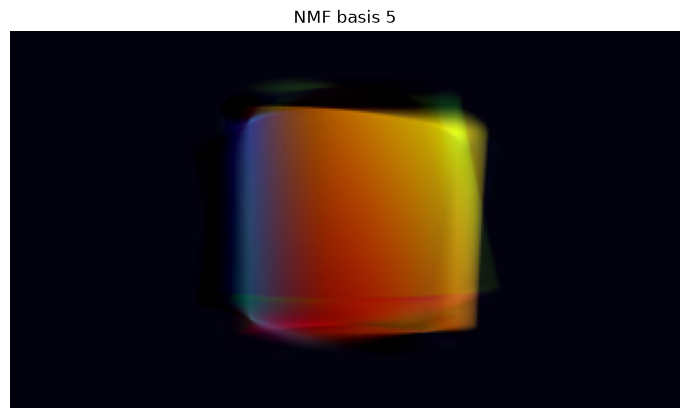

In [16]:
nmf_k5, nmf_model_k5 = nmf_reduce_time(frames, n_components=5)

for i, basis in enumerate(nmf_k5):
    show_image(basis, title=f"NMF basis {i+1}")


### NMF variation 4 — Initialisation sensitivity

NMF is non-convex: different initialisations can yield different local minima. Below we compare the default `nndsvda` init with a random init (same k = 3).


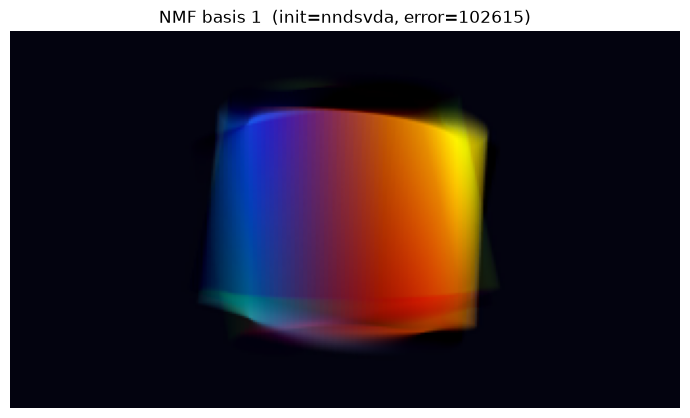

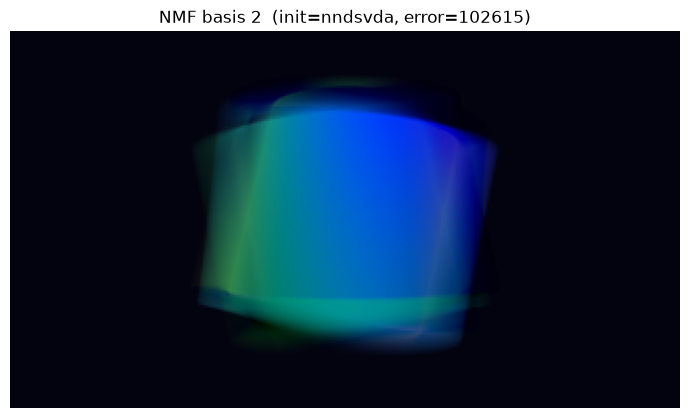

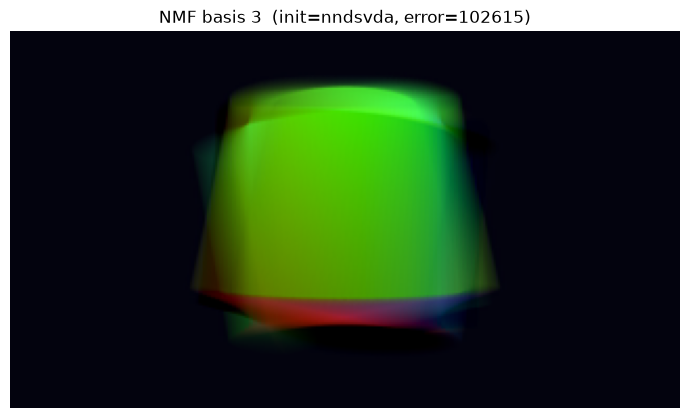

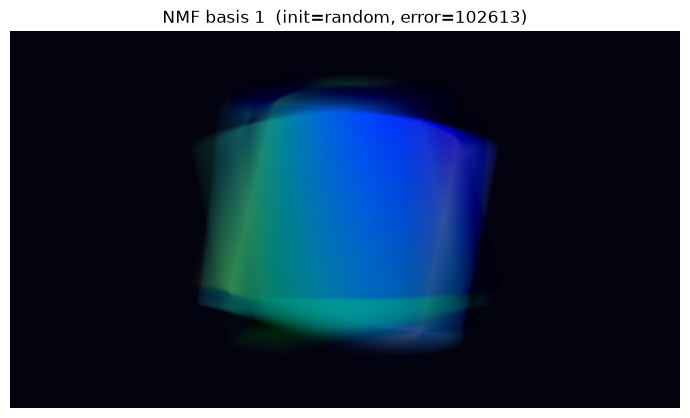

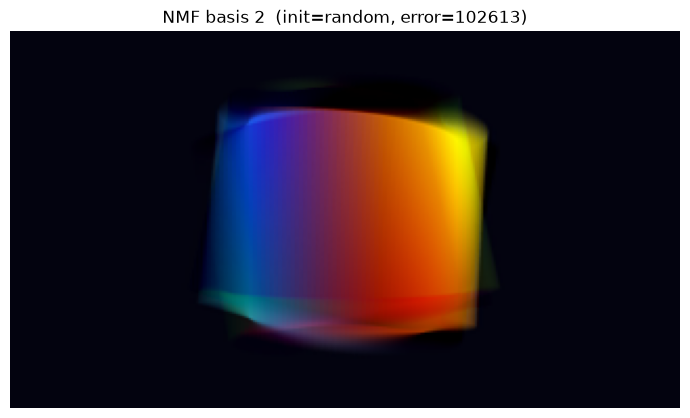

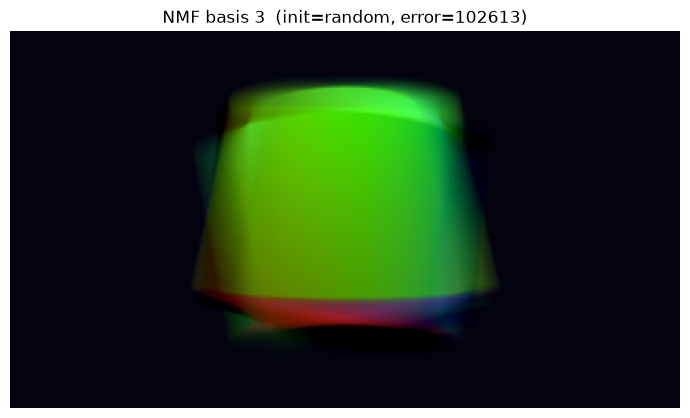

In [17]:
for init_name in ["nndsvda", "random"]:
    bases, model = nmf_reduce_time(frames, n_components=3, init=init_name, random_state=42)
    for i, basis in enumerate(bases):
        show_image(
            basis,
            title=f"NMF basis {i+1}  (init={init_name}, error={model.reconstruction_err_:.0f})",
        )


## Robust PCA — low-rank background + sparse motion

### How it works

Robust PCA decomposes the frame matrix into:

$$\mathbf{X} = \mathbf{L} + \mathbf{S}$$

| Term | Structure | Role in video |
|------|-----------|---------------|
| **L** | Low-rank | Static background, lighting drift |
| **S** | Sparse | Moving objects, flicker, outliers |

We solve this with **ADMM** (Alternating Direction Method of Multipliers):
1. **L-step** — soft-thresholded SVD (nuclear norm minimisation).
2. **S-step** — element-wise soft thresholding (L1 sparsity).

The scalar **λ** controls sparsity of **S**. The default `λ = 1/√max(N, D)` is a common choice (Candès et al.).

The single-image summary is the dominant **spatial mode** of **L** (top right singular vector).


In [18]:
def _robust_pca(flat, lam=None, max_iter=100, tol=1e-7):
    """Robust PCA via ADMM. Returns low-rank L and sparse S."""
    m, n = flat.shape
    if lam is None:
        lam = 1.0 / np.sqrt(max(m, n))

    norm_x = np.linalg.norm(flat, "fro")
    low_rank = np.zeros_like(flat)
    sparse = np.zeros_like(flat)
    dual = np.zeros_like(flat)
    mu = 1.25 / (np.linalg.norm(flat, 2) + 1e-8)
    mu_bar = mu * 1e7
    rho = 1.5

    for _ in range(max_iter):
        temp = flat - sparse + dual / mu
        u, sigma, vt = np.linalg.svd(temp, full_matrices=False)
        sigma_thresh = np.maximum(sigma - 1.0 / mu, 0)
        rank = int(np.sum(sigma_thresh > 0))
        if rank == 0:
            low_rank = np.zeros_like(flat)
        else:
            low_rank = (u[:, :rank] * sigma_thresh[:rank]) @ vt[:rank, :]

        temp = flat - low_rank + dual / mu
        sparse = np.sign(temp) * np.maximum(np.abs(temp) - lam / mu, 0)

        residual = flat - low_rank - sparse
        dual = dual + mu * residual
        mu = min(mu * rho, mu_bar)

        if np.linalg.norm(residual, "fro") / (norm_x + 1e-8) < tol:
            break

    return low_rank, sparse


def robust_pca_reduce_time(frames, lam=None, max_iter=100):
    """Decompose frames into L + S. Returns background image and spatial modes of L."""
    n, h, w, c = frames.shape
    flat = frames.reshape(n, -1).astype(np.float64)

    low_rank, sparse = _robust_pca(flat, lam=lam, max_iter=max_iter)
    _, _, vt = np.linalg.svd(low_rank, full_matrices=False)
    background = _rescale_to_uint8(vt[0].reshape(h, w, c))

    return background, low_rank, sparse, vt


### Robust PCA variation 1 — Background image

The dominant spatial mode of **L** is the compressed static scene.


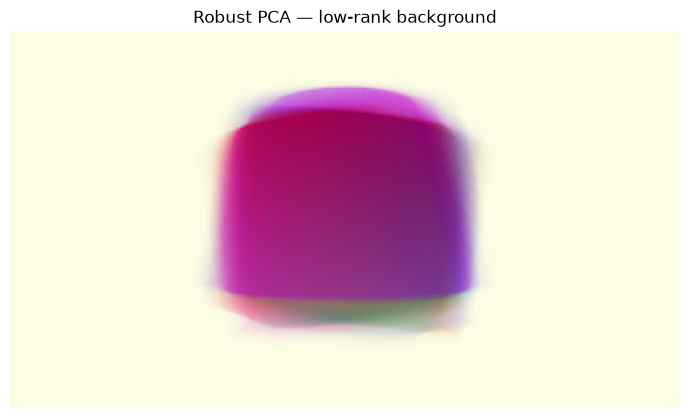

In [19]:
background, low_rank, sparse_residual, rpca_vt = robust_pca_reduce_time(frames)
_, h, w, c = frames.shape

show_image(background, title="Robust PCA — low-rank background")


### Robust PCA variation 2 — Motion heatmap

Averaging |**S**| over time highlights pixels that change frequently — a motion saliency map.


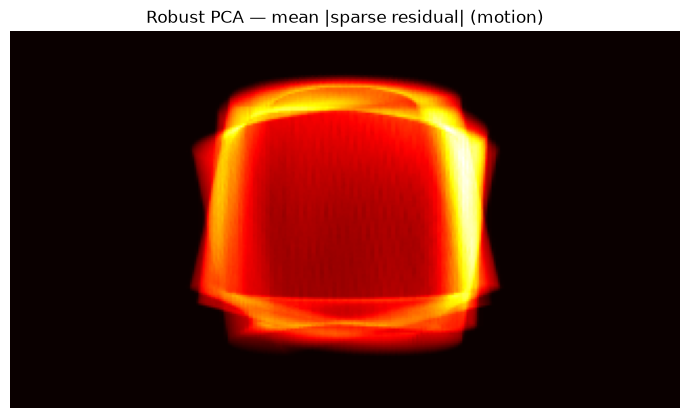

In [20]:
motion_map = np.abs(sparse_residual).mean(axis=0).reshape(h, w, c).mean(axis=2)
motion_map = _rescale_to_uint8(motion_map)

show_image(motion_map, title="Robust PCA — mean |sparse residual| (motion)", cmap="hot")


### Robust PCA variation 3 — Spatial modes of L

The SVD of **L** gives spatial modes analogous to PCA components, but derived from the low-rank background only.


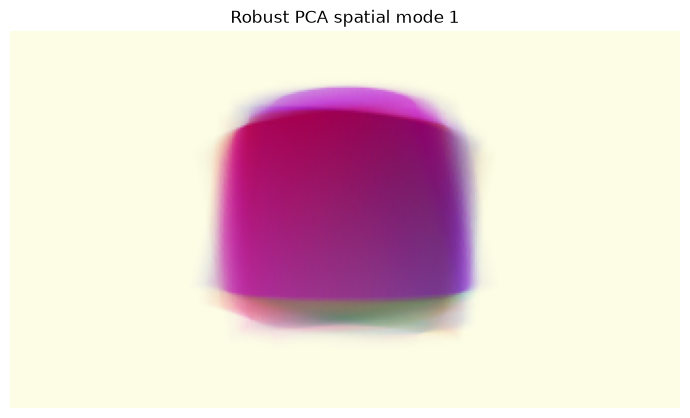

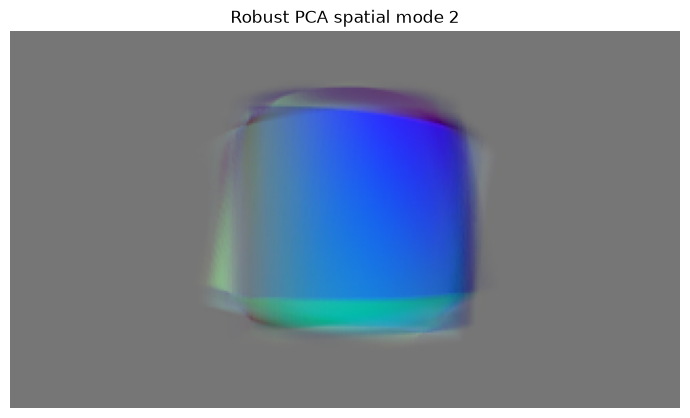

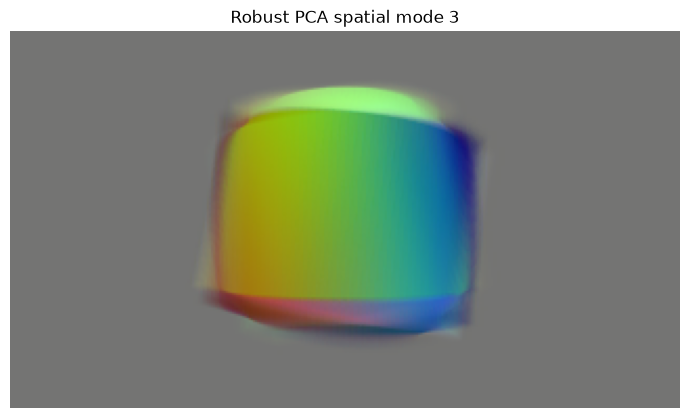

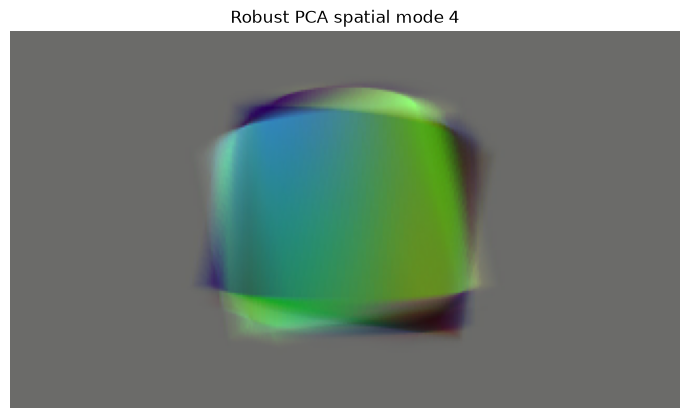

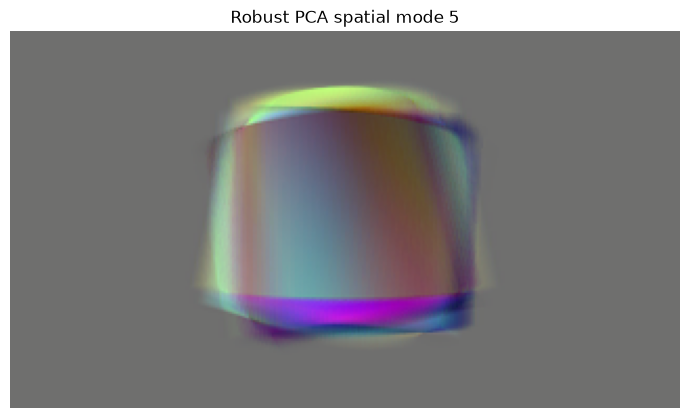

In [21]:
for i in range(5):
    mode = _rescale_to_uint8(rpca_vt[i].reshape(h, w, c))
    show_image(mode, title=f"Robust PCA spatial mode {i+1}")


### Robust PCA variation 4 — Sparsity parameter λ

Smaller λ → sparser **S** (less motion captured, cleaner background). Larger λ → denser **S** (more detail moved to residual).

We compare three multiples of the default λ.


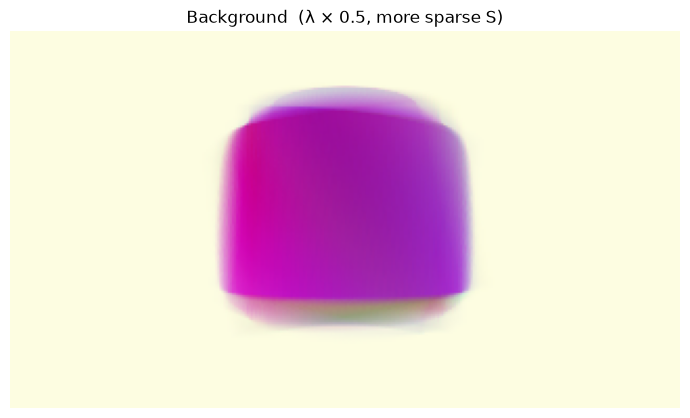

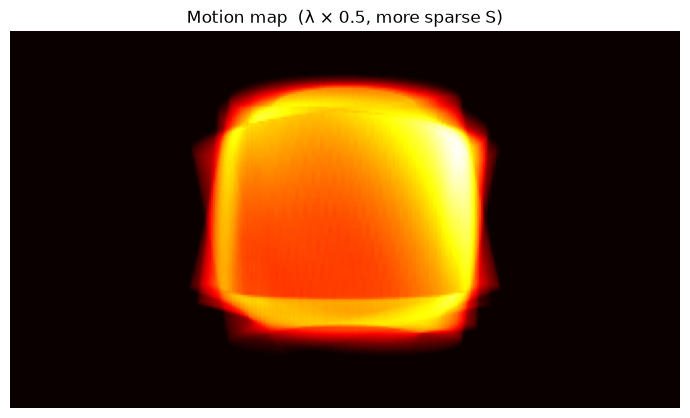

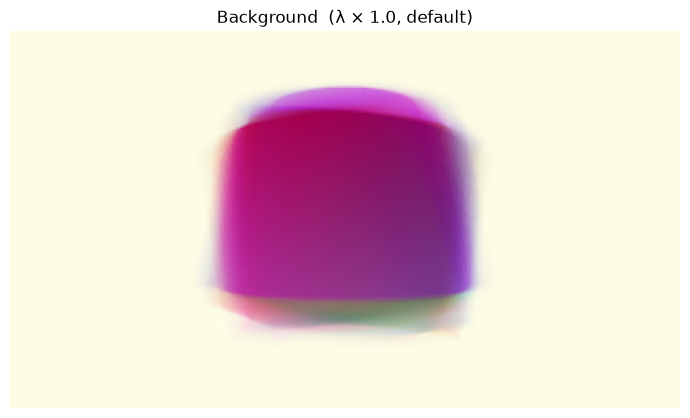

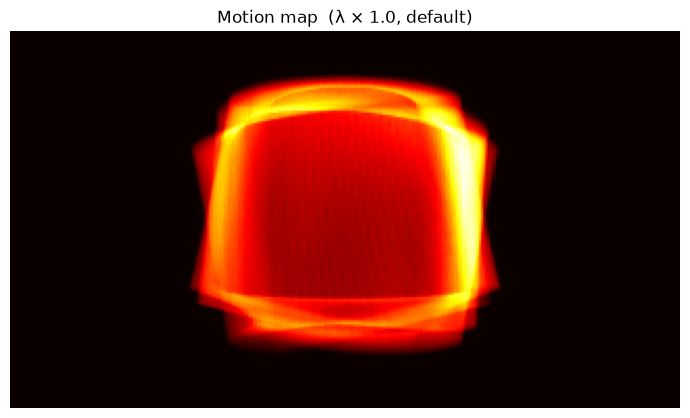

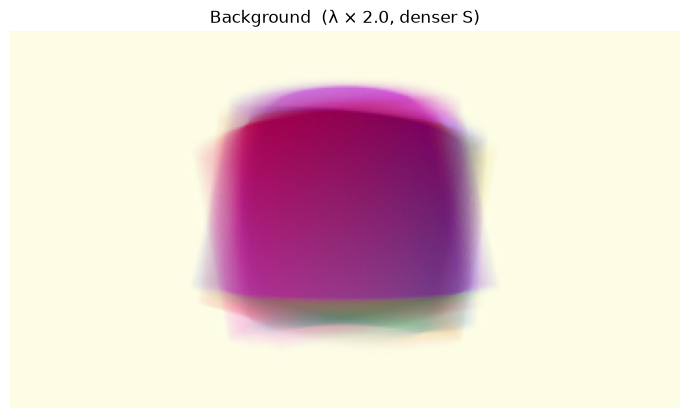

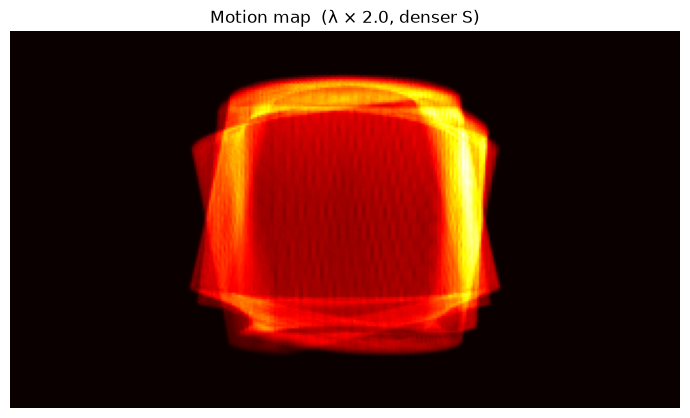

In [22]:
default_lam = 1.0 / np.sqrt(max(len(frames), frames[0].size))

for factor, label in [(0.5, "more sparse S"), (1.0, "default"), (2.0, "denser S")]:
    lam = default_lam * factor
    bg, _, sparse, _ = robust_pca_reduce_time(frames, lam=lam)
    motion = _rescale_to_uint8(
        np.abs(sparse).mean(axis=0).reshape(h, w, c).mean(axis=2)
    )

    show_image(bg, title=f"Background  (λ × {factor}, {label})")
    show_image(motion, title=f"Motion map  (λ × {factor}, {label})", cmap="hot")


### Robust PCA variation 5 — Per-frame decomposition

For selected frames, we show the original, its low-rank part **L**, and the sparse residual |**S**| as three separate figures.


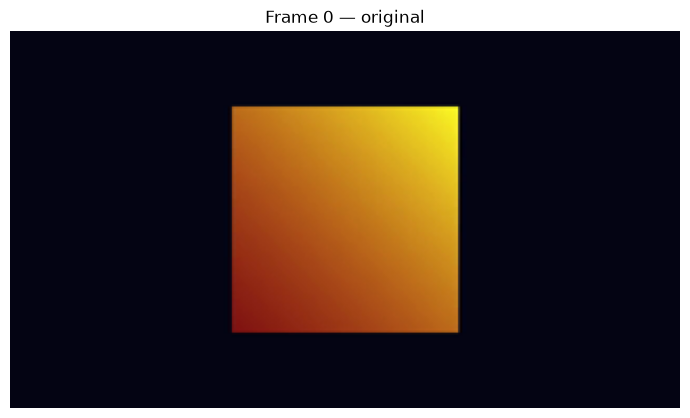

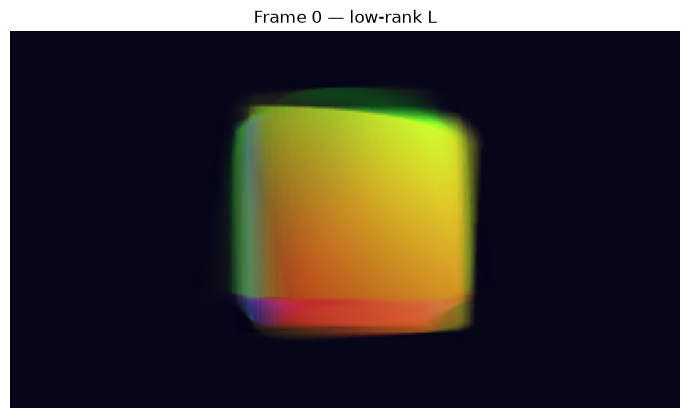

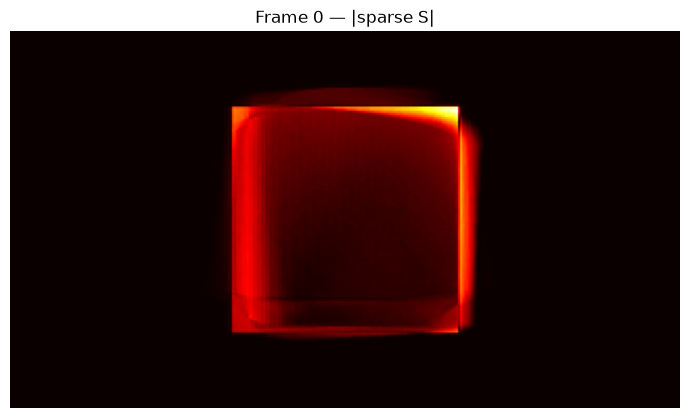

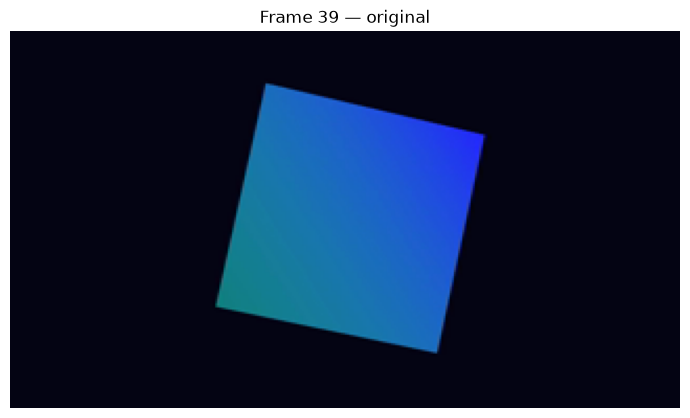

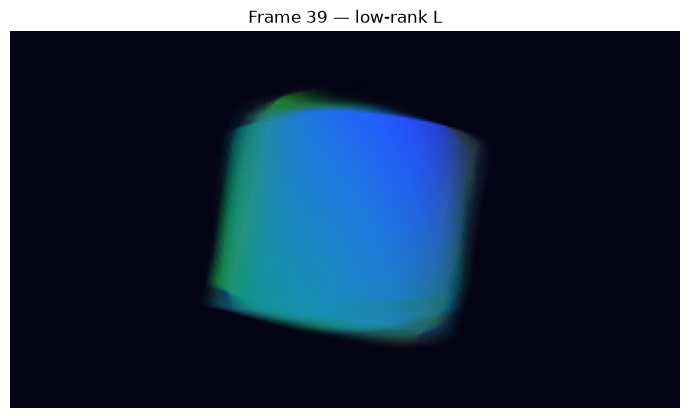

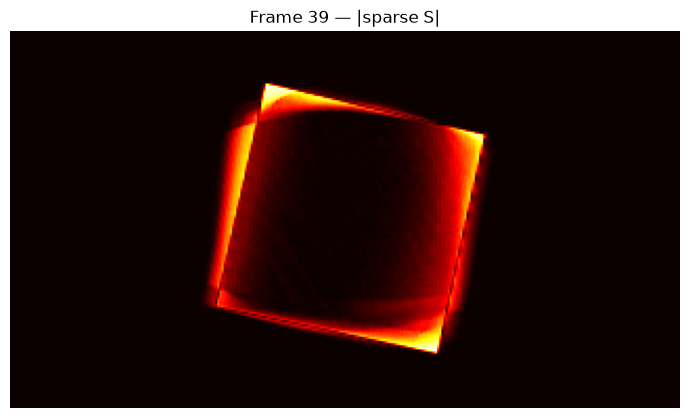

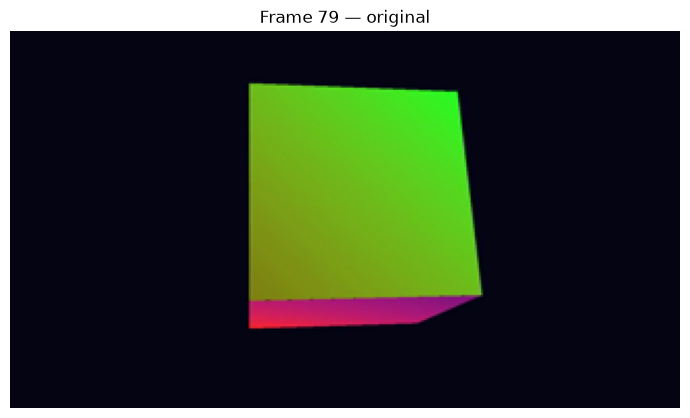

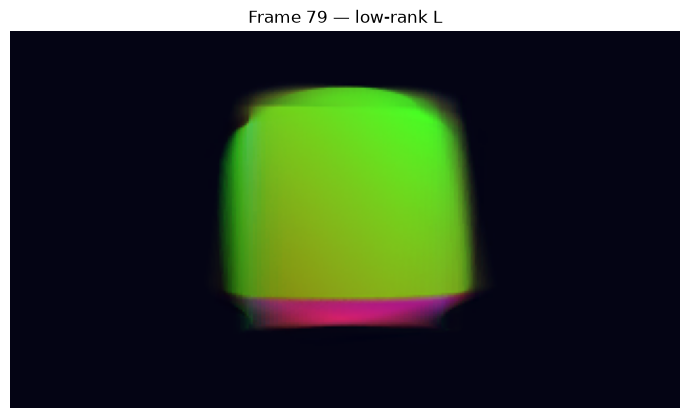

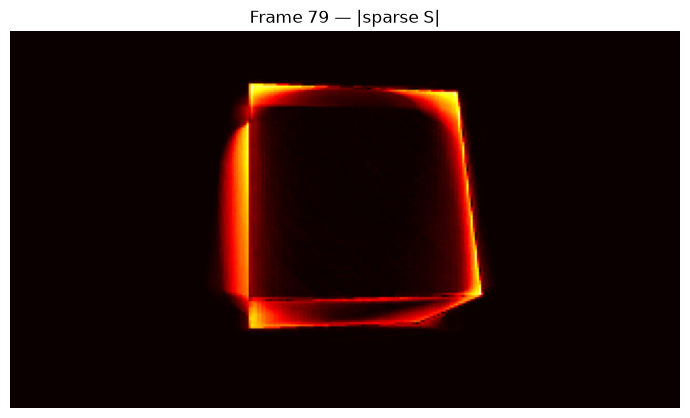

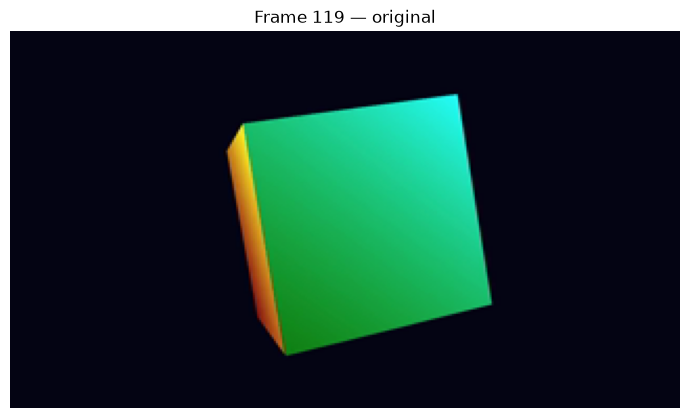

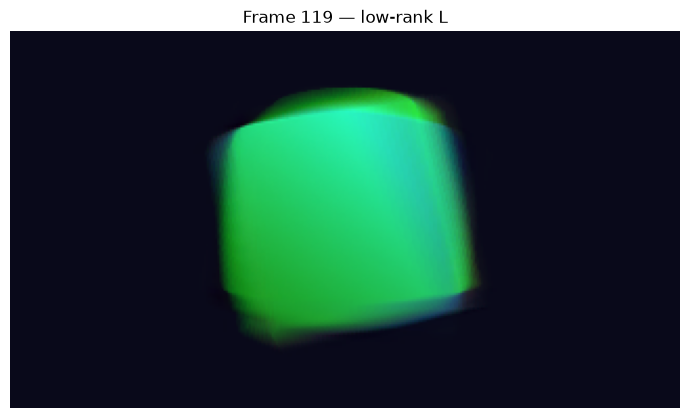

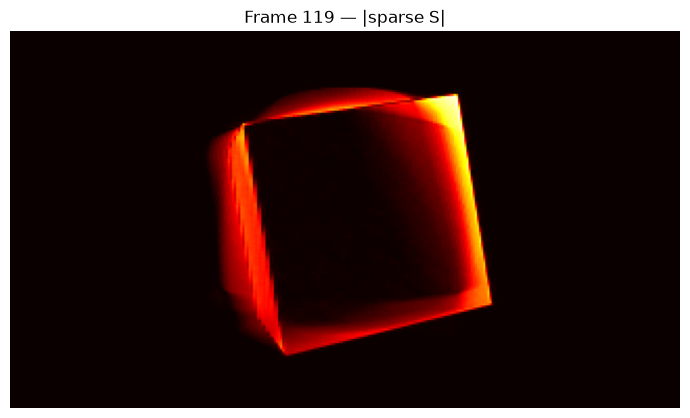

In [23]:
sample_indices = np.linspace(0, len(frames) - 1, 4, dtype=int)

for idx in sample_indices:
    original = frames[idx]
    l_frame = _rescale_to_uint8(low_rank[idx].reshape(h, w, c))
    s_vis = _rescale_to_uint8(np.abs(sparse_residual[idx].reshape(h, w, c)).mean(axis=2))

    show_image(original, title=f"Frame {idx} — original")
    show_image(l_frame, title=f"Frame {idx} — low-rank L")
    show_image(s_vis, title=f"Frame {idx} — |sparse S|", cmap="hot")


### Side-by-side recap at k = 1

Three separate figures summarising the single-image output of each native method.


/Users/remi/Programs/other/ml-experiments/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


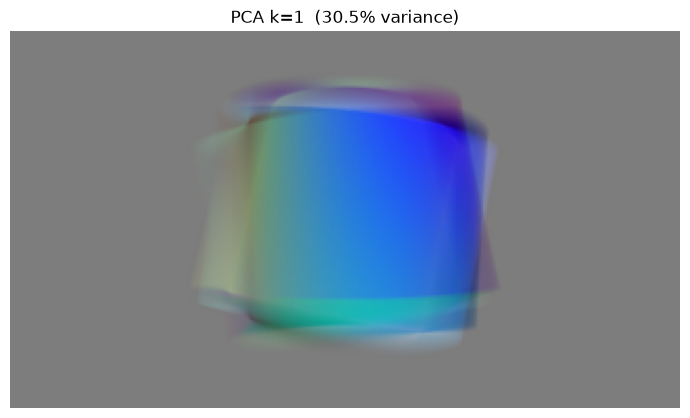

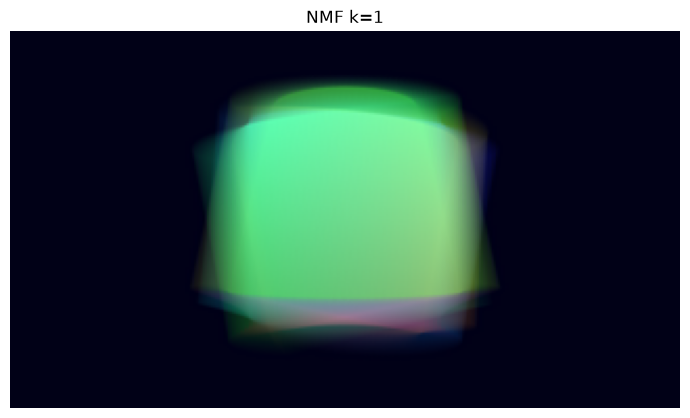

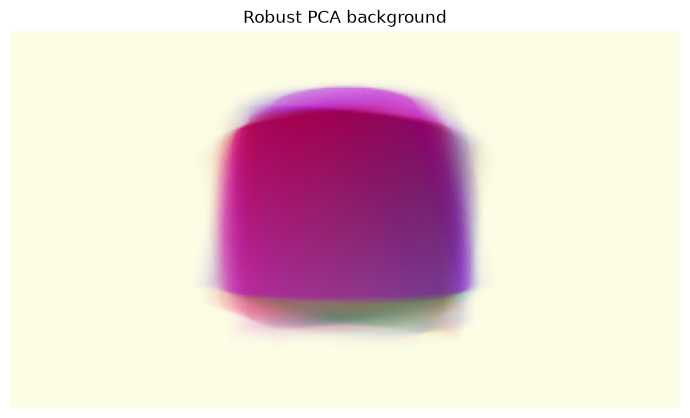

In [24]:
pca_single, pca_model, _ = pca_reduce_time(frames, n_components=1)
nmf_single, _ = nmf_reduce_time(frames, n_components=1)

show_image(
    pca_single[0],
    title=f"PCA k=1  ({pca_model.explained_variance_ratio_[0]*100:.1f}% variance)",
)
show_image(nmf_single[0], title="NMF k=1")
show_image(background, title="Robust PCA background")


## Experiment 2: RGB channel reduction

### Problem setup

For a single frame, each pixel has a 3-vector `(R, G, B)`. We want one scalar per pixel.

**Luminance greyscale** uses fixed ITU-R BT.709 weights. **PCA greyscale** finds the direction of maximum colour variance across all pixels in the frame — a data-driven alternative.


In [25]:
def pca_greyscale(image):
    """Project RGB pixels onto the first principal component."""
    h, w, c = image.shape
    pixels = image.reshape(-1, 3).astype(np.float64)

    pca = PCA(n_components=1)
    projected = pca.fit_transform(pixels).ravel()
    projected = _rescale_to_uint8(projected)
    return projected.reshape(h, w), pca


def luminance_greyscale(image):
    """Standard BT.709 luminance conversion."""
    return (
        0.2126 * image[:, :, 0]
        + 0.7152 * image[:, :, 1]
        + 0.0722 * image[:, :, 2]
    ).astype(np.uint8)


### Channel reduction — per-frame comparison

Each sample frame is shown as three separate figures: original RGB, luminance greyscale, and PCA greyscale.


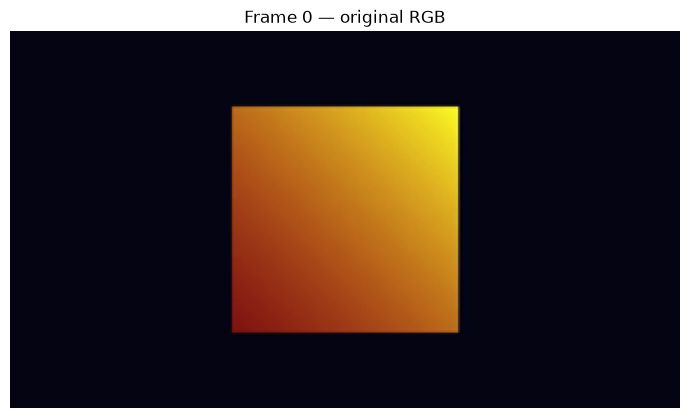

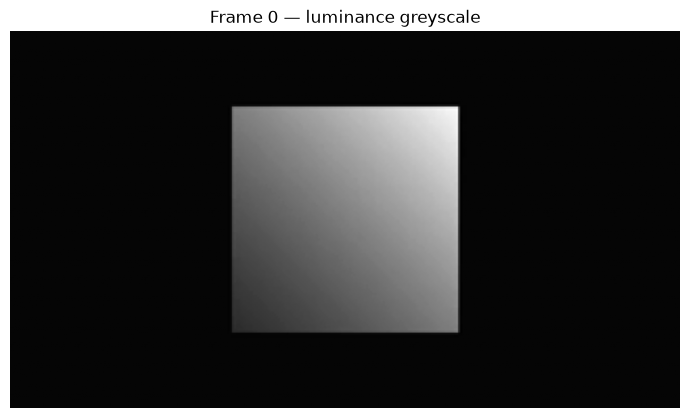

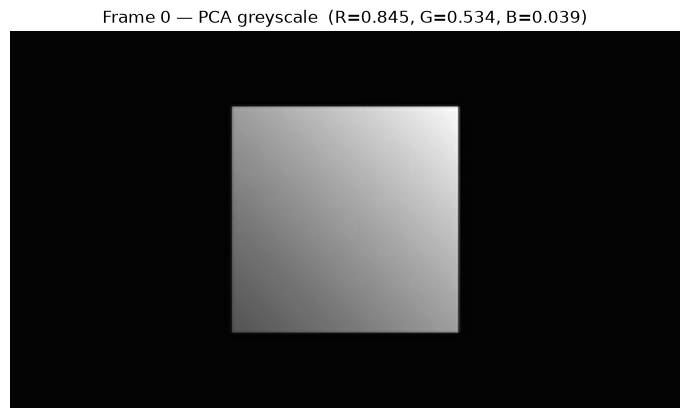

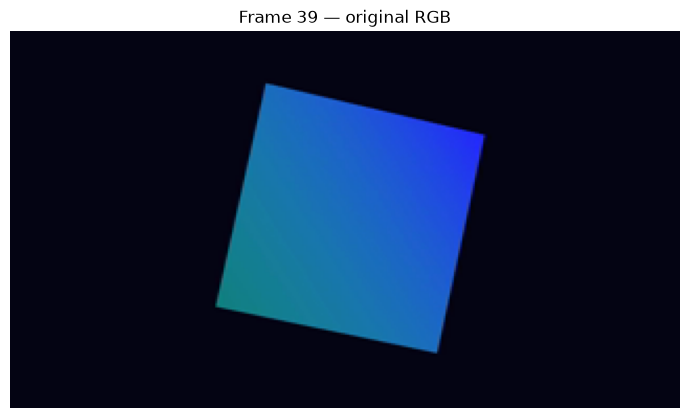

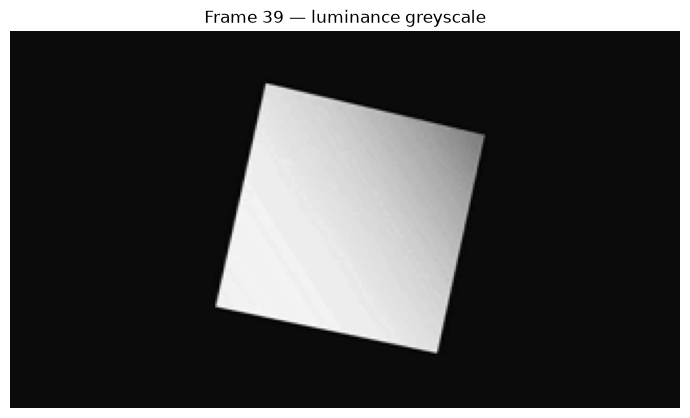

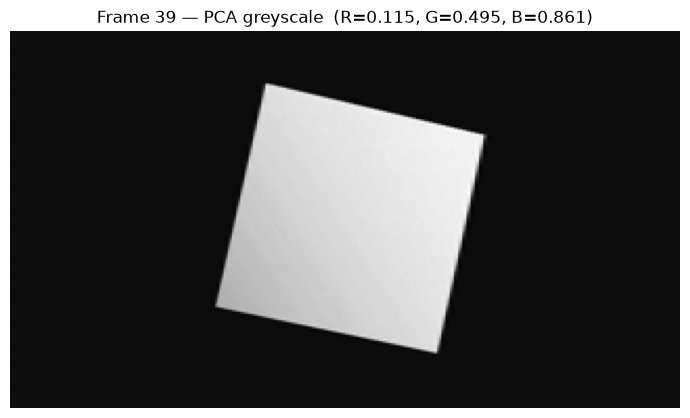

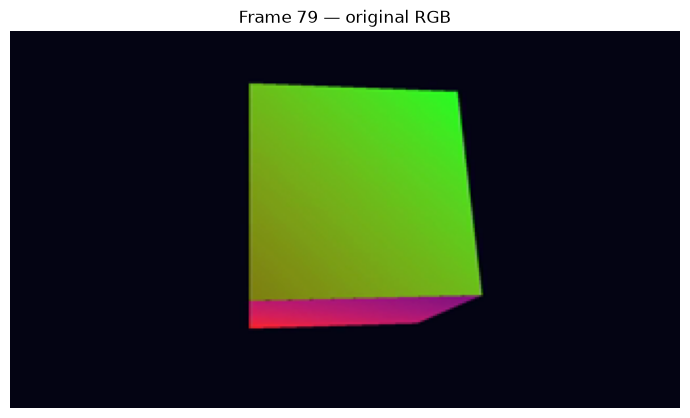

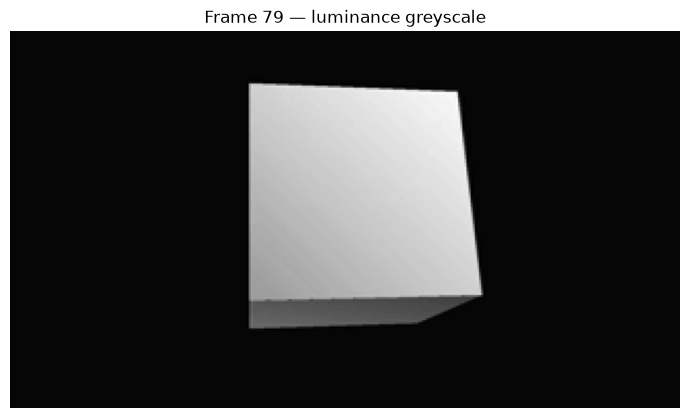

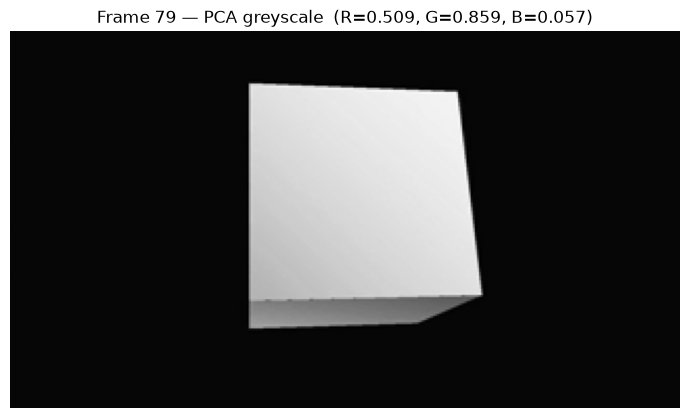

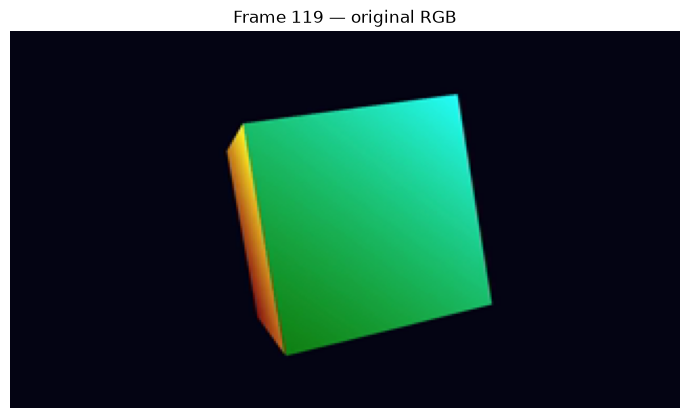

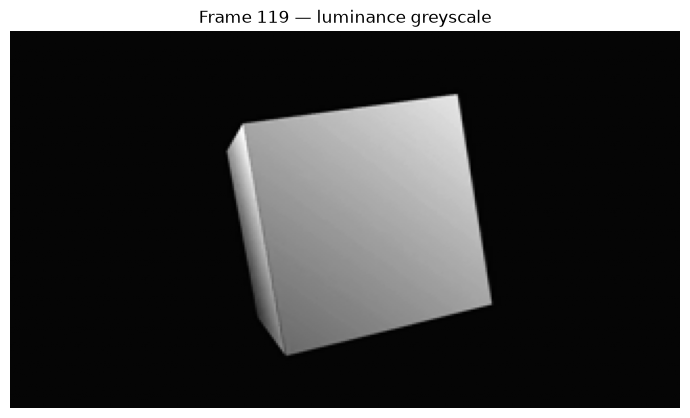

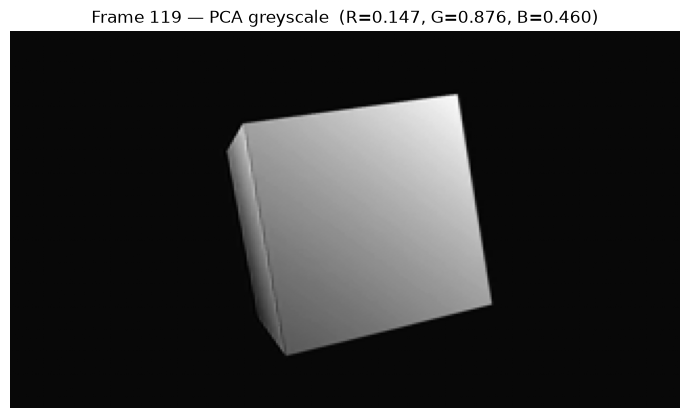

In [26]:
sample_indices = np.linspace(0, len(frames) - 1, 4, dtype=int)

for idx in sample_indices:
    frame = frames[idx]
    pca_grey, pca_obj = pca_greyscale(frame)
    lum_grey = luminance_greyscale(frame)
    w = pca_obj.components_[0]

    show_image(frame, title=f"Frame {idx} — original RGB")
    show_image(lum_grey, title=f"Frame {idx} — luminance greyscale", cmap="gray")
    show_image(
        pca_grey,
        title=f"Frame {idx} — PCA greyscale  (R={w[0]:.3f}, G={w[1]:.3f}, B={w[2]:.3f})",
        cmap="gray",
    )


## Analysis

### PCA (time)
- Linear, orthogonal decomposition centred on the temporal mean.
- Component 1 ≈ dominant shared appearance; higher components capture deviations.
- Signed components can include negative pixel values before rescaling.
- Scree plot and reconstruction MSE guide the choice of *k*.

### NMF (time)
- Non-negative, parts-based decomposition without centring.
- Bases are visually interpretable but depend on initialisation (non-convex).
- Activations over time show when each part is present.

### Robust PCA (time)
- Explicitly separates static background from sparse per-frame changes.
- λ trades off background cleanliness vs motion capture.
- Best when the scene has a clear static structure and localized motion.

### PCA (channels)
- Data-driven greyscale; often close to luminance on natural images.
- Weights vary per frame depending on colour distribution.

### Further experiments
- NMF greyscale for channel reduction
- Kernel PCA for non-linear time modes
- ICA to separate statistically independent temporal signals


## Extra: t-SNE frame exploration

t-SNE is **not** a native image compression method — it returns 2D coordinates, not pixel-space bases. It is useful for exploring which frames are visually similar and selecting a diverse subset.

**Perplexity** controls the effective neighbourhood size (must be < N). Lower values focus on local structure; higher values consider more global layout.


In [27]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


def tsne_reduce_time(frames, n_select=5, perplexity=30, random_state=42):
    """Embed frames in 2D and pick cluster-centroid representatives."""
    n = frames.shape[0]
    flat = frames.reshape(n, -1).astype(np.float64)

    effective_perplexity = min(perplexity, n - 1)
    tsne = TSNE(
        n_components=2,
        perplexity=effective_perplexity,
        random_state=random_state,
    )
    embedding = tsne.fit_transform(flat)

    kmeans = KMeans(n_clusters=n_select, random_state=random_state, n_init=10)
    kmeans.fit(embedding)

    selected = []
    for center in kmeans.cluster_centers_:
        dists = np.linalg.norm(embedding - center, axis=1)
        selected.append(np.argmin(dists))
    selected = np.array(sorted(set(selected)))

    return frames[selected], selected, embedding


selected_frames, selected_idx, embedding = tsne_reduce_time(frames, n_select=5)


### t-SNE variation 1 — Embedding scatter

Points coloured by frame index. Nearby points are visually similar frames; colour gradients reveal temporal trajectories.


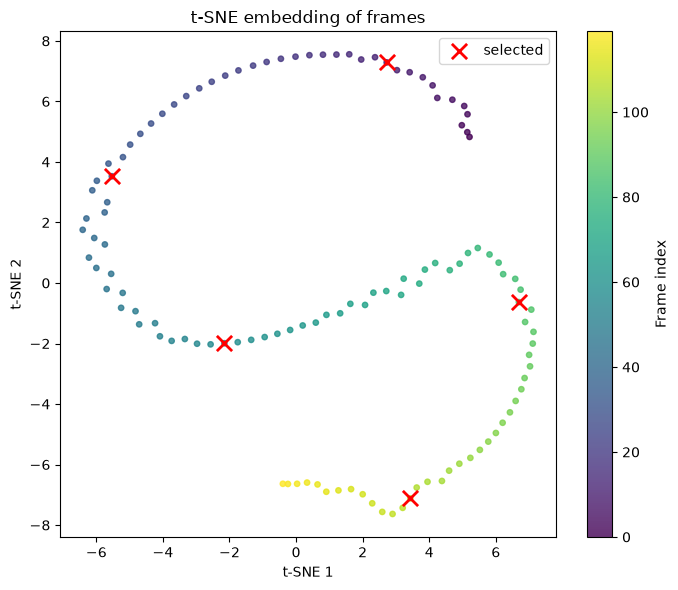

In [28]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=np.arange(len(frames)), cmap="viridis", s=15, alpha=0.8,
)
plt.scatter(
    embedding[selected_idx, 0], embedding[selected_idx, 1],
    c="red", s=120, marker="x", linewidths=2, zorder=5, label="selected",
)
plt.colorbar(scatter, label="Frame index")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE embedding of frames")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()


### t-SNE variation 2 — Selected representative frames

One figure per representative frame chosen by k-means on the embedding.


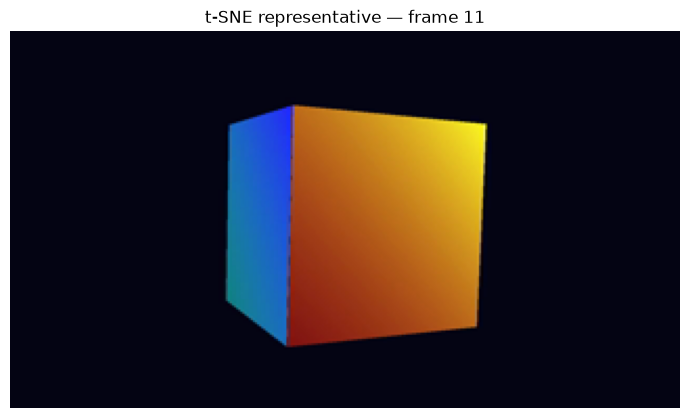

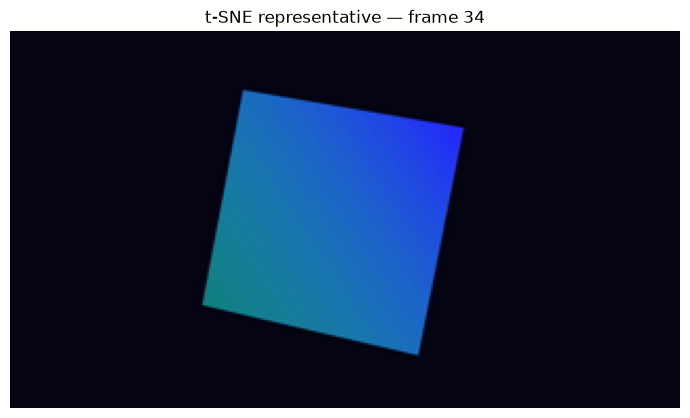

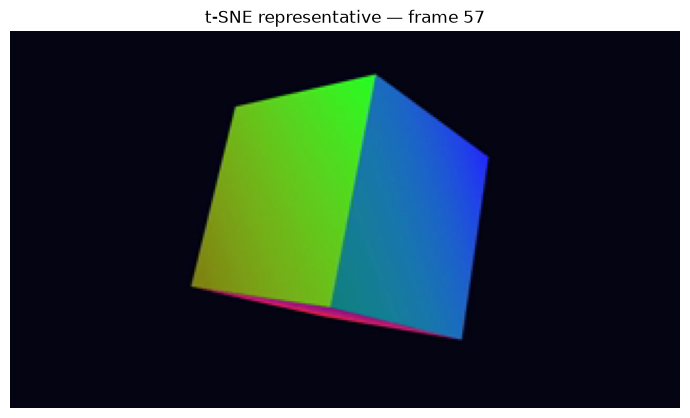

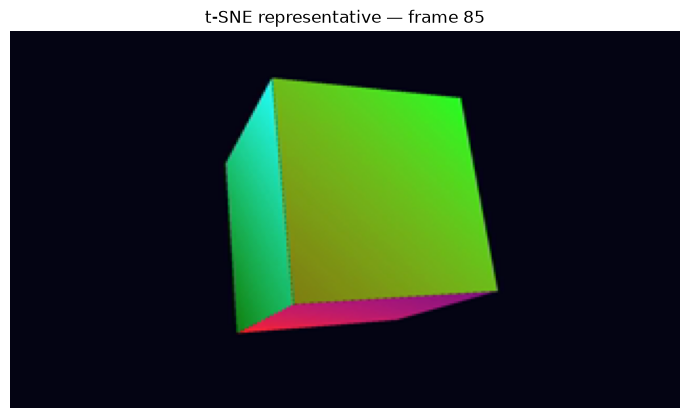

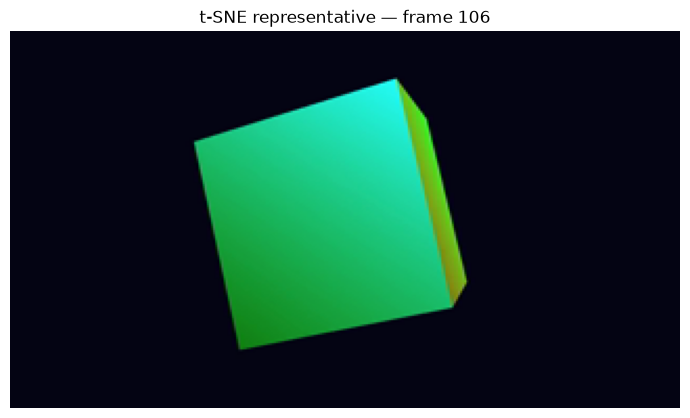

In [29]:
for idx in selected_idx:
    show_image(frames[idx], title=f"t-SNE representative — frame {idx}")


### t-SNE variation 3 — Perplexity comparison

Different perplexity values change the local/global balance of the embedding. Each setting is plotted separately.


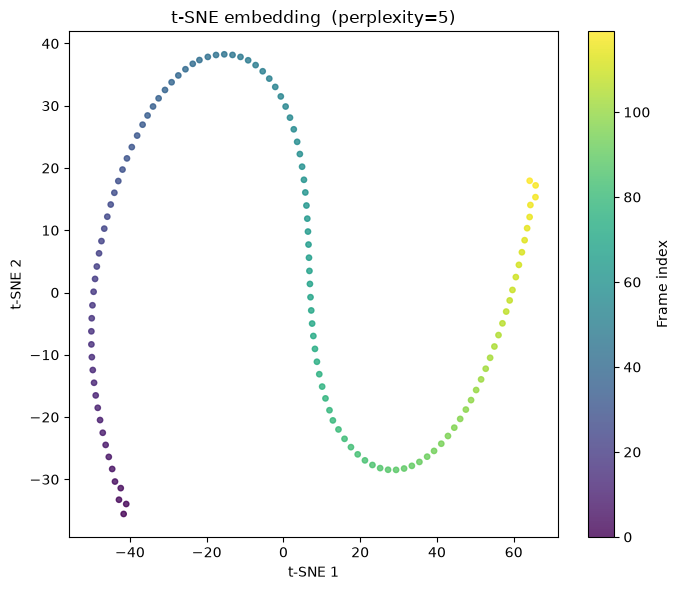

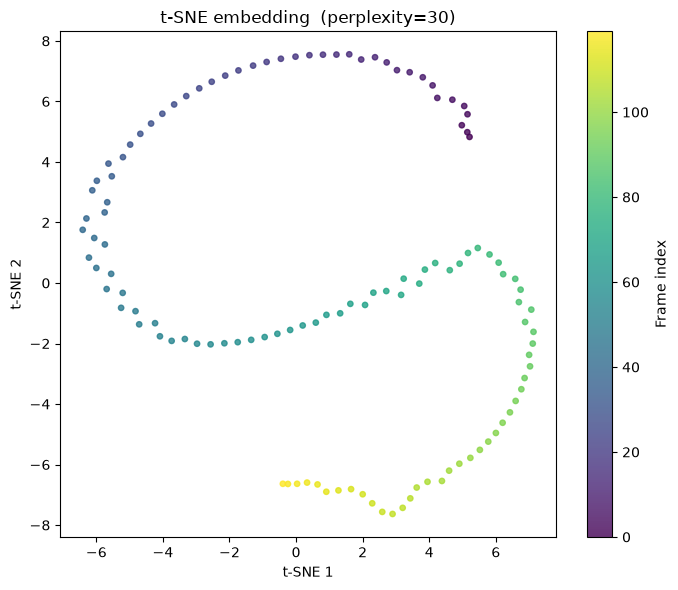

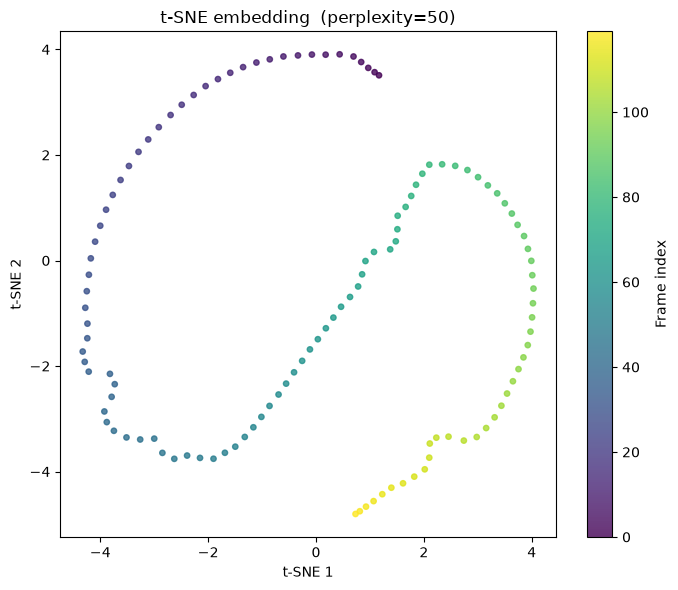

In [30]:
for perp in [5, 30, 50]:
    effective = min(perp, len(frames) - 1)
    tsne = TSNE(n_components=2, perplexity=effective, random_state=42)
    emb = tsne.fit_transform(frames.reshape(len(frames), -1).astype(np.float64))

    plt.figure(figsize=(7, 6))
    plt.scatter(emb[:, 0], emb[:, 1], c=np.arange(len(frames)), cmap="viridis", s=15, alpha=0.8)
    plt.colorbar(label="Frame index")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(f"t-SNE embedding  (perplexity={perp})")
    plt.tight_layout()
    plt.show()
    plt.close()
